In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
def knn():
    X = []
    Y = []
    Label  = []
    for i in range(100):
        r = random.randint(1,100)
        if len(X) < 50:
            X.append(r)
        else:
            Y.append(r)
    for _ in range(50):
        r = random.randint(1,3)
        Label.append(r)
    data = pd.DataFrame({'X' : X,'Y' : Y,'Label' : Label})
    # plt.scatter(data['X'],data['Y'],color='red')
    # plt.show()
    new_X , new_Y = 0 , 0
    for i in range(2):
        if i == 1: 
            r = random.randint(1,100)
            new_X += r
        else:
            r = random.randint(1,100) # random number
            new_Y += r
    masofalar = {} # distance 
    k = int(input('Kni kiriting etibor bering sinflar 3 ta'))
    if k > 0:
        pass
    else:
        print(f"Kni notogri kiritildi {k}")
        return
    for i in range(50):
        d = ((new_X - data.at[i, 'X'])**2 + (new_Y - data.at[i, 'Y'])**2)**0.5
        masofalar[i] = d
    def masofani_ol(element):
        return element[1]
    dict_qiladi = masofalar.items()  
    osuvchi = sorted(dict_qiladi, key=masofani_ol)
    sinfi = []
    for i in range(k):
        min_indexi = osuvchi[i][0] 
        label_qiymat = data.at[min_indexi, 'Label']
        sinfi.append(label_qiymat)
        print(f"{i+1}-eng yaqin qo'shnini indexi: {min_indexi}, Label: {label_qiymat}")
    yangi_label = max(set(sinfi), key=sinfi.count)
    count = [sinfi.count(x) for x in set(sinfi)]
    max_takrorlanishlar = max(count)
    if count.count(max_takrorlanishlar) > 1:
        print("Kni tanlashda xato")
        return 
    yangi_label = max(set(sinfi), key=sinfi.count)
    yangi_qator = len(data)
    data.loc[yangi_qator] = [new_X, new_Y, yangi_label]
    plt.figure(figsize=(10, 6))
    colors = {1: 'blue', 2: 'green', 3: 'orange'}
    for sinf in data['Label'].unique():
        sinf_boyicha = data[data['Label'] == sinf]
        plt.scatter(sinf_boyicha['X'][:-1], sinf_boyicha['Y'][:-1], c=colors[sinf], label=f'Label {sinf}')
    plt.scatter(new_X, new_Y, c='red', marker='x', s=200, linewidths=3, label='Yangi nuqta')
    plt.title(f"KNN {k}ta bolganda")
    plt.xlabel("X koordinata")
    plt.ylabel("Y koordinata")
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f"X {new_X} va Y {new_Y} bolganda")
    print(data.tail(10))
knn()

1-eng yaqin qo'shnini indexi: 37, Label: 3
2-eng yaqin qo'shnini indexi: 23, Label: 1
3-eng yaqin qo'shnini indexi: 47, Label: 2
4-eng yaqin qo'shnini indexi: 29, Label: 3
5-eng yaqin qo'shnini indexi: 39, Label: 2
6-eng yaqin qo'shnini indexi: 27, Label: 2
7-eng yaqin qo'shnini indexi: 16, Label: 1
8-eng yaqin qo'shnini indexi: 34, Label: 3
9-eng yaqin qo'shnini indexi: 40, Label: 3
10-eng yaqin qo'shnini indexi: 43, Label: 2
Kni tanlashda xato


The variables are written in English below.


New point to classify: X=53, Y=71
------------------------------
1-nearest neighbor: Point(x=43, y=80), Label: 1
2-nearest neighbor: Point(x=64, y=62), Label: 1
3-nearest neighbor: Point(x=51, y=55), Label: 1
4-nearest neighbor: Point(x=51, y=54), Label: 2
5-nearest neighbor: Point(x=44, y=86), Label: 2
6-nearest neighbor: Point(x=42, y=85), Label: 3
7-nearest neighbor: Point(x=63, y=54), Label: 1
8-nearest neighbor: Point(x=35, y=82), Label: 3
9-nearest neighbor: Point(x=34, y=60), Label: 1
10-nearest neighbor: Point(x=74, y=79), Label: 1
----------
RESULT:
The new point at (X=53, Y=71) belongs to Label: 1
Assigned Color: blue
----------


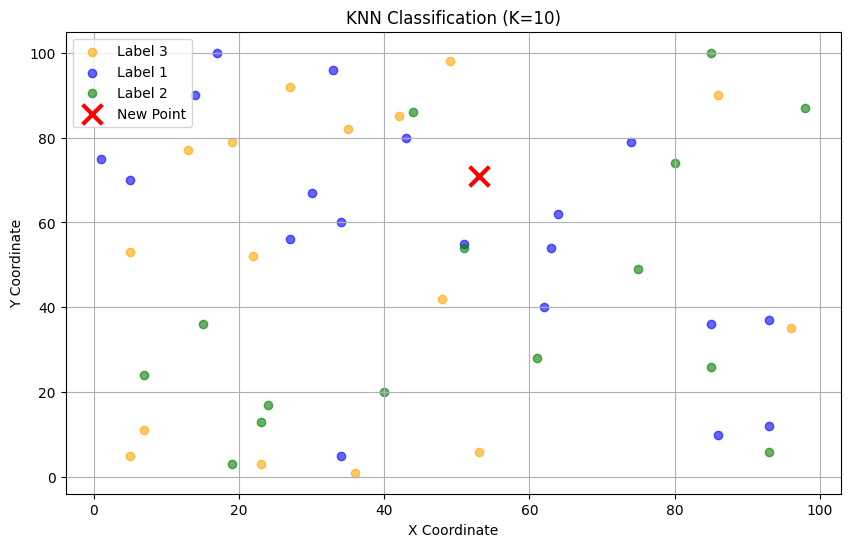

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

def knn():
    x_coords = []
    y_coords = []
    labels = []
    
    # Generate random data
    for i in range(50):
        x_coords.append(random.randint(1, 100))
        y_coords.append(random.randint(1, 100))
        labels.append(random.randint(1, 3))
        
    data = pd.DataFrame({'X': x_coords, 'Y': y_coords, 'Label': labels})
    
    # Generate new random data point
    new_x = random.randint(1, 100)
    new_y = random.randint(1, 100)
    
    distances = [] 
    k = int(input('Enter K (Note: classes are 1, 2, 3): '))
    
    if k <= 0:
        print(f"Invalid K: {k}")
        return
        
    # Calculate Euclidean distances
    for i in range(len(data)):
        point_x = data.at[i, 'X']
        point_y = data.at[i, 'Y']
        dist = ((new_x - point_x)**2 + (new_y - point_y)**2)**0.5
        # Index o'rniga koordinatalar va masofani saqlaymiz
        distances.append({
            'x': point_x,
            'y': point_y,
            'dist': dist,
            'label': data.at[i, 'Label']
        })
    
    # Sort by distance
    sorted_neighbors = sorted(distances, key=lambda x: x['dist'])
    
    neighbor_classes = []
    print(f"\nNew point to classify: X={new_x}, Y={new_y}")
    print("-" * 30)
    
    for i in range(k):
        neighbor = sorted_neighbors[i]
        neighbor_classes.append(neighbor['label'])
        print(f"{i+1}-nearest neighbor: Point(x={neighbor['x']}, y={neighbor['y']}), Label: {neighbor['label']}")
    
    # Voting logic
    counts = [neighbor_classes.count(x) for x in set(neighbor_classes)]
    if counts.count(max(counts)) > 1:
        print("\nCannot determine a single majority class.")
        return 
        
    predicted_label = max(set(neighbor_classes), key=neighbor_classes.count)
    
    # Visualization
    plt.figure(figsize=(10, 6))
    colors = {1: 'blue', 2: 'green', 3: 'orange'}
    
    for class_type in data['Label'].unique():
        subset = data[data['Label'] == class_type]
        plt.scatter(subset['X'], subset['Y'], c=colors[class_type], label=f'Label {class_type}', alpha=0.6)
    # Bashorat qilingan natijani terminalga chiqarish
    print("-" * 10)
    print(f"RESULT:")
    print(f"The new point at (X={new_x}, Y={new_y}) belongs to Label: {predicted_label}")
    print(f"Assigned Color: {colors[predicted_label]}")
    print("-" * 10)
    # Plotting the new point
    plt.scatter(new_x, new_y, c='red', marker='x', s=200, linewidths=3, label='New Point')
    
    plt.title(f"KNN Classification (K={k})")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True)
    plt.show()
    

knn()

変数は日本語では次のように記述されます。


分類する新しい点: X=73, Y=73
------------------------------
1番目に近い点: 座標(x=63, y=68), クラス: 2
2番目に近い点: 座標(x=70, y=62), クラス: 1
3番目に近い点: 座標(x=85, y=67), クラス: 1
4番目に近い点: 座標(x=63, y=82), クラス: 1
5番目に近い点: 座標(x=70, y=93), クラス: 3
6番目に近い点: 座標(x=65, y=53), クラス: 1
7番目に近い点: 座標(x=54, y=62), クラス: 2
8番目に近い点: 座標(x=52, y=63), クラス: 3
9番目に近い点: 座標(x=88, y=55), クラス: 3
10番目に近い点: 座標(x=98, y=73), クラス: 2
----------
【判定結果】
新しい点 (X=73, Y=73) は クラス: 1 に分類されました。
割り当てられた色: blue
----------


/home/gayratbek/university/leetcode/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24231 (\N{CJK UNIFIED IDEOGRAPH-5EA7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gayratbek/university/leetcode/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gayratbek/university/leetcode/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gayratbek/university/leetcode/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gayratbek/university/leetcode/.venv/lib/python

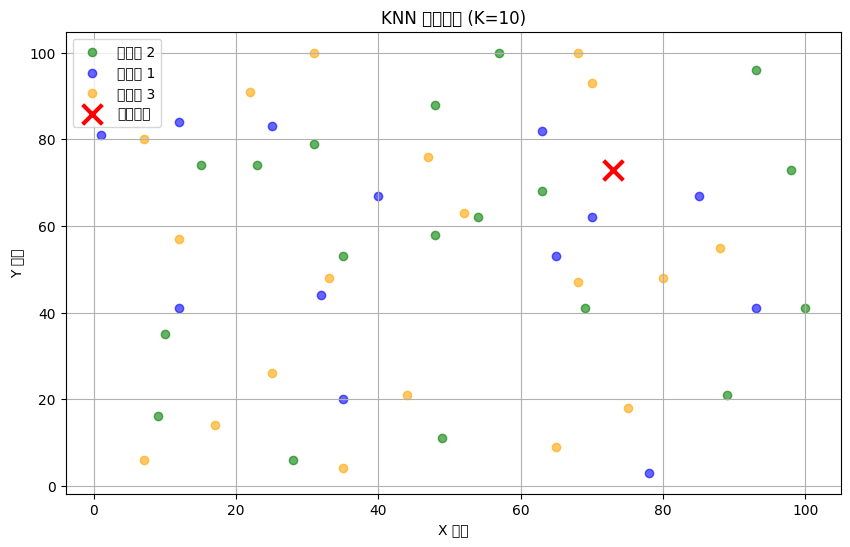

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

def knn():
    # 座標とラベルのリスト
    x_zahyo = []
    y_zahyo = []
    bunrui_list = []
    
    # ランダムデータの生成
    for i in range(50):
        x_zahyo.append(random.randint(1, 100))
        y_zahyo.append(random.randint(1, 100))
        bunrui_list.append(random.randint(1, 3))
        
    data = pd.DataFrame({'X': x_zahyo, 'Y': y_zahyo, 'Bunrui': bunrui_list})
    
    # 新しいデータポイントの生成
    atarashii_x = random.randint(1, 100)
    atarashii_y = random.randint(1, 100)
    
    kyori_list = [] 
    k_chi = int(input('K値を入力してください（クラス：1, 2, 3）: '))
    
    if k_chi <= 0:
        print(f"無効なK値です: {k_chi}")
        return
        
    # ユークリッド距離の計算
    for i in range(len(data)):
        ten_x = data.at[i, 'X']
        ten_y = data.at[i, 'Y']
        kyori = ((atarashii_x - ten_x)**2 + (atarashii_y - ten_y)**2)**0.5
        
        kyori_list.append({
            'x': ten_x,
            'y': ten_y,
            'kyori': kyori,
            'bunrui': data.at[i, 'Bunrui']
        })
    
    # 距離でソート
    souto_zumi_kinjo = sorted(kyori_list, key=lambda x: x['kyori'])
    
    kinjo_no_bunrui = []
    print(f"\n分類する新しい点: X={atarashii_x}, Y={atarashii_y}")
    print("-" * 30)
    
    for i in range(k_chi):
        kinjo = souto_zumi_kinjo[i]
        kinjo_no_bunrui.append(kinjo['bunrui'])
        print(f"{i+1}番目に近い点: 座標(x={kinjo['x']}, y={kinjo['y']}), クラス: {kinjo['bunrui']}")
    
    # 多数決のロジック
    counts = [kinjo_no_bunrui.count(x) for x in set(kinjo_no_bunrui)]
    if counts.count(max(counts)) > 1:
        print("\n多数決でクラスを特定できませんでした。別のK値を試してください。")
        return 
        
    yosoku_bunrui = max(set(kinjo_no_bunrui), key=kinjo_no_bunrui.count)
    
    # 可視化
    plt.figure(figsize=(10, 6))
    iro_map = {1: 'blue', 2: 'green', 3: 'orange'}
    
    for b_type in data['Bunrui'].unique():
        bubun_data = data[data['Bunrui'] == b_type]
        plt.scatter(bubun_data['X'], bubun_data['Y'], c=iro_map[b_type], label=f'クラス {b_type}', alpha=0.6)
    
    # 結果の表示
    print("-" * 10)
    print(f"【判定結果】")
    print(f"新しい点 (X={atarashii_x}, Y={atarashii_y}) は クラス: {yosoku_bunrui} に分類されました。")
    print(f"割り当てられた色: {iro_map[yosoku_bunrui]}")
    print("-" * 10)
    
    # 新しい点をプロット
    plt.scatter(atarashii_x, atarashii_y, c='red', marker='x', s=200, linewidths=3, label='新しい点')
    
    plt.title(f"KNN 分類結果 (K={k_chi})")
    plt.xlabel("X 座標")
    plt.ylabel("Y 座標")
    plt.legend()
    plt.grid(True)
    plt.show()

knn()